# 07 - Retreinar Modelo LSTM com 5 Fatores (Versão Melhorada)

## 🎯 Objetivo
Retreinar o modelo LSTM com os 5 fatores (Execution, Sentiment, Macro, Competition, Policy) com possibilidade de:
- ✅ Ajustar hiperparâmetros (learning rate, dropout, regularização)
- ✅ Modificar arquitetura do modelo (LSTM units, dense units)
- ✅ Experimentar diferentes estratégias de treinamento
- ✅ Comparar resultados com modelo anterior
- ✅ Salvar melhorias com timestamp

## 📊 Problema Identificado
- Modelo atual falha em algumas variações de preço
- Às vezes preço real sobe e previsão desce
- Erros significativos em períodos voláteis
- Necessidade de melhorias na capacidade de previsão

In [11]:
# ====================================
# 1. IMPORTS E CONFIGURAÇÕES
# ====================================

# Imports padrão
import sys
import warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

# Setup de caminhos
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

# Imports científicos
import numpy as np
import pandas as pd
import yaml
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ML/Deep Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Customizados
from src.data.data_processor import StockDataProcessor
from src.models.feature_registry import get_feature_registry

# Configuração global
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"✅ Attention Mechanism: Habilitado")

✅ TensorFlow: 2.15.0
✅ Data: 2026-01-05 18:48:03
✅ Attention Mechanism: Habilitado


## 🔧 SEÇÃO 1: CONFIGURAÇÕES EDITÁVEIS

Edite as configurações abaixo para customizar o treinamento:

```python
# Datas e símbolo
SYMBOL = 'TSLA'
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

# Arquitetura do Modelo (MODIFICÁVEL)
SEQUENCE_LENGTH = 60              # Número de dias históricos para cada sequência
LSTM_UNITS = [100, 50]            # Unidades de cada camada LSTM [camada1, camada2]
DROPOUT_RATE = 0.2                # Taxa de dropout (0-1, maior = mais regularização)
DENSE_UNITS = 25                  # Unidades da camada densa
REGULARIZATION_L2 = 0.001         # L2 Regularization (maior = mais regularização)

# Treinamento (MODIFICÁVEL)
LEARNING_RATE = 0.001             # Learning rate do optimizer Adam
BATCH_SIZE = 32                   # Batch size (reduzir se falta memória)
EPOCHS = 100                       # Máximo de épocas
EARLY_STOP_PATIENCE = 20          # Paciência para EarlyStopping
REDUCE_LR_PATIENCE = 10           # Paciência para ReduceLROnPlateau

# Dados
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
```

In [12]:
# ====================================
# 2. DEFINIR HIPERPARÂMETROS DO MODELO
# ====================================

# Datas e símbolo
SYMBOL = 'TSLA'
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

# Configuração Final do Modelo
model_config = {
    'sequence_length': 70,              # Dias históricos por sequência
    'lstm_units': [160, 80],            # Unidades LSTM (2 camadas)
    'dropout_rate': 0.28,               # Taxa de dropout
    'dense_units': 32,                  # Unidades camada densa
    'learning_rate': 0.0005,            # Learning rate
    'batch_size': 32,                   # Batch size
    'epochs': 150,                      # Máximo de épocas
    'regularization_l2': 0.001,         # L2 regularization
    'early_stop_patience': 30,          # Paciência early stopping
    'reduce_lr_patience': 15,           # Paciência reduce LR
    'train_ratio': 0.7,
    'val_ratio': 0.15
}

print("=" * 80)
print("CONFIGURAÇÃO DO MODELO")
print("=" * 80)
print("\n📊 Hiperparâmetros:")
for key, value in model_config.items():
    print(f"  {key:20}: {value}")

print("\n📈 Arquitetura:")
print(f"  • Entrada: {model_config['sequence_length']} timesteps × N features")
print(f"  • LSTM 1: {model_config['lstm_units'][0]} unidades + Dropout({model_config['dropout_rate']})")
print(f"  • LSTM 2: {model_config['lstm_units'][1]} unidades + Dropout({model_config['dropout_rate']})")
print(f"  • Dense: {model_config['dense_units']} unidades + Dropout({model_config['dropout_rate']*0.5:.2f})")
print(f"  • Output: 1 (preço previsto)")

CONFIGURAÇÃO DO MODELO

📊 Hiperparâmetros:
  sequence_length     : 70
  lstm_units          : [160, 80]
  dropout_rate        : 0.28
  dense_units         : 32
  learning_rate       : 0.0005
  batch_size          : 32
  epochs              : 150
  regularization_l2   : 0.001
  early_stop_patience : 30
  reduce_lr_patience  : 15
  train_ratio         : 0.7
  val_ratio           : 0.15

📈 Arquitetura:
  • Entrada: 70 timesteps × N features
  • LSTM 1: 160 unidades + Dropout(0.28)
  • LSTM 2: 80 unidades + Dropout(0.28)
  • Dense: 32 unidades + Dropout(0.14)
  • Output: 1 (preço previsto)


In [13]:
print("=" * 80)
print("CARREGANDO DADOS E ENGENHARIA DE FEATURES")
print("=" * 80)

# Carregar dados
processor = StockDataProcessor(SYMBOL, START_DATE, END_DATE)
feature_registry = get_feature_registry('../src/config/model_config.yaml')

# Ativar os 5 grupos de features
print("\n✅ Ativando grupos de features:")
feature_registry.enable_feature_group('execution')
feature_registry.enable_feature_group('sentiment')
feature_registry.enable_feature_group('macro')
feature_registry.enable_feature_group('competition')
feature_registry.enable_feature_group('policy')

for group, status in feature_registry.get_feature_groups_status().items():
    if status['enabled']:
        print(f"   • {group.capitalize()}: {status['feature_count']} features")

# Processar dados
raw_df = processor.load_data()
processed_df = processor.process_with_features(
    enable_competition=True,
    enable_policy=True
)

# Features Técnicas
print("\n📊 Adicionando features técnicas:")

# Volatilidade (desvio padrão móvel 20 dias)
processed_df['Volatility_20'] = processed_df['Close'].rolling(window=20).std()

# Momentum (mudança em 20 dias)
processed_df['Momentum_20'] = processed_df['Close'].diff(20)

# MACD
exp1 = processed_df['Close'].ewm(span=12, adjust=False).mean()
exp2 = processed_df['Close'].ewm(span=26, adjust=False).mean()
processed_df['MACD'] = exp1 - exp2

# Log Returns (retorno logarítmico)
processed_df['Log_Returns'] = np.log(processed_df['Close'] / processed_df['Close'].shift(1))

# ATR (Average True Range)
high = processed_df['High'] if 'High' in processed_df.columns else processed_df['Close']
low = processed_df['Low'] if 'Low' in processed_df.columns else processed_df['Close']
close_prev = processed_df['Close'].shift(1)
tr1 = high - low
tr2 = np.abs(high - close_prev)
tr3 = np.abs(low - close_prev)
tr = np.maximum(tr1, np.maximum(tr2, tr3))
processed_df['ATR'] = tr.rolling(window=14).mean()

# Preencher NaN
processed_df = processed_df.fillna(method='bfill').fillna(method='ffill')

print(f"   ✅ Volatility_20, Momentum_20, MACD")
print(f"   ✅ Log_Returns, ATR")

print(f"\n✅ Dados: {len(processed_df)} registros | {processed_df.shape[1]} features")
print(f"   Período: {processed_df.index[0].date()} a {processed_df.index[-1].date()}")

2026-01-05 18:48:03,957 - src.data.feature_engineer - INFO - TeslaFeatureEngineer inicializado para TSLA
2026-01-05 18:48:03,957 - src.data.data_processor - INFO - StockDataProcessor inicializado para TSLA
2026-01-05 18:48:03,957 - src.models.feature_registry - INFO - Grupo 'execution' ativado
2026-01-05 18:48:03,966 - src.models.feature_registry - INFO - Grupo 'sentiment' ativado
2026-01-05 18:48:03,967 - src.models.feature_registry - INFO - Grupo 'macro' ativado
2026-01-05 18:48:03,968 - src.models.feature_registry - INFO - Grupo 'competition' ativado
2026-01-05 18:48:03,970 - src.models.feature_registry - INFO - Grupo 'policy' ativado
2026-01-05 18:48:03,971 - src.data.data_processor - INFO - Carregando dados para TSLA


CARREGANDO DADOS E ENGENHARIA DE FEATURES

✅ Ativando grupos de features:
   • Core: 3 features
   • Execution: 0 features
   • Sentiment: 0 features
   • Macro: 0 features
   • Competition: 0 features
   • Policy: 0 features


2026-01-05 18:48:03,991 - src.data.cache_manager - INFO - Dados carregados do cache: TSLA
2026-01-05 18:48:03,993 - src.models.feature_registry - INFO - Grupo 'competition' ativado
2026-01-05 18:48:03,994 - src.data.data_processor - INFO - Features de competição ativadas
2026-01-05 18:48:03,995 - src.models.feature_registry - INFO - Grupo 'policy' ativado
2026-01-05 18:48:03,996 - src.data.data_processor - INFO - Features de política ativadas
2026-01-05 18:48:03,999 - src.data.data_processor - INFO - Aplicando engenharia de features...
2026-01-05 18:48:04,000 - src.data.feature_engineer - INFO - Iniciando engenharia de features...
2026-01-05 18:48:04,052 - src.data.feature_engineer - INFO - Carregando dados macro do cache: 2020-01-02 a 2025-12-29
2026-01-05 18:48:04,068 - src.data.cache_manager - INFO - Dados carregados do cache: ^GSPC
2026-01-05 18:48:04,068 - src.data.feature_engineer - INFO - ✅ S&P 500: 1505 registros carregados
2026-01-05 18:48:04,084 - src.data.cache_manager - INF


📊 Adicionando features técnicas:
   ✅ Volatility_20, Momentum_20, MACD
   ✅ Log_Returns, ATR

✅ Dados: 1254 registros | 41 features
   Período: 2020-12-31 a 2025-12-29


In [14]:
print("\n" + "=" * 80)
print("PREPARAR SEQUÊNCIAS PARA LSTM")
print("=" * 80)

def prepare_sequences(df, feature_names, target_col='Close', 
                      sequence_length=60, train_ratio=0.7, val_ratio=0.15):
    """Prepara sequências para LSTM"""
    data = df[feature_names].copy().dropna()
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    target_idx = feature_names.index(target_col)
    
    X, y = [], []
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i])
        y.append(scaled_data[i, target_idx])
    
    X, y = np.array(X), np.array(y)
    
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)
    
    return {
        'X_train': X[:train_size],
        'y_train': y[:train_size],
        'X_val': X[train_size:train_size + val_size],
        'y_val': y[train_size:train_size + val_size],
        'X_test': X[train_size + val_size:],
        'y_test': y[train_size + val_size:],
        'scaler': scaler,
        'feature_names': feature_names
    }

# Extrair features
all_features = [col for col in processed_df.columns if col not in ['Volume']]
n_features_total = len(all_features)

# Usar todas as features disponíveis
feature_names = all_features

# Garantir que Close está no início
if 'Close' in feature_names:
    feature_names = ['Close'] + [f for f in feature_names if f != 'Close']

# Preparar dados
data_config = prepare_sequences(
    processed_df,
    feature_names,
    sequence_length=model_config['sequence_length'],
    train_ratio=model_config['train_ratio'],
    val_ratio=model_config['val_ratio']
)

X_train = data_config['X_train']
y_train = data_config['y_train']
X_val = data_config['X_val']
y_val = data_config['y_val']
X_test = data_config['X_test']
y_test = data_config['y_test']
scaler = data_config['scaler']
feature_names = data_config['feature_names']

print(f"\n✅ Sequências Preparadas:")
print(f"   X_train: {X_train.shape}  (samples, timesteps, features)")
print(f"   y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_test:  {y_test.shape}")
print(f"\n   Features utilizadas: {len(feature_names)}")
print(f"   Primeiras 5 features: {feature_names[:5]}")


PREPARAR SEQUÊNCIAS PARA LSTM

✅ Sequências Preparadas:
   X_train: (828, 70, 40)  (samples, timesteps, features)
   y_train: (828,)
   X_val:   (177, 70, 40)
   y_val:   (177,)
   X_test:  (179, 70, 40)
   y_test:  (179,)

   Features utilizadas: 40
   Primeiras 5 features: ['Close', 'Open', 'High', 'Low', 'Adj Close']


In [15]:
print("\n" + "=" * 80)
print("CONSTRUIR E COMPILAR MODELO LSTM")
print("=" * 80)

def build_lstm_model(config, n_features):
    """Constrói modelo LSTM para previsão de preços"""
    model = Sequential()
    
    # Input
    model.add(Input(shape=(config['sequence_length'], n_features)))
    
    # Primeira camada LSTM
    model.add(LSTM(
        units=config['lstm_units'][0],
        return_sequences=True,
        kernel_regularizer=l2(config['regularization_l2']),
        recurrent_regularizer=l2(config['regularization_l2'])
    ))
    model.add(Dropout(config['dropout_rate']))
    
    # Segunda camada LSTM
    model.add(LSTM(
        units=config['lstm_units'][1],
        return_sequences=False,
        kernel_regularizer=l2(config['regularization_l2']),
        recurrent_regularizer=l2(config['regularization_l2'])
    ))
    model.add(Dropout(config['dropout_rate']))
    
    # Camada Dense
    model.add(Dense(
        units=config['dense_units'],
        activation='relu',
        kernel_regularizer=l2(config['regularization_l2'])
    ))
    model.add(Dropout(config['dropout_rate'] * 0.5))
    
    # Output
    model.add(Dense(1, activation='linear'))
    
    # Compilar
    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

# Criar modelo
model = build_lstm_model(model_config, X_train.shape[2])

print("\n📊 RESUMO DA ARQUITETURA:")
model.summary()

print("\n💾 Preparando treinamento...")
models_dir = Path('../data/models')
models_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

config_before = model_config.copy()
config_before['timestamp_start'] = timestamp
config_before['n_features'] = X_train.shape[2]


CONSTRUIR E COMPILAR MODELO LSTM

📊 RESUMO DA ARQUITETURA:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 70, 160)           128640    
                                                                 
 dropout_3 (Dropout)         (None, 70, 160)           0         
                                                                 
 lstm_3 (LSTM)               (None, 80)                77120     
                                                                 
 dropout_4 (Dropout)         (None, 80)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2592      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                            

In [16]:
print("\n" + "=" * 80)
print("CONFIGURAR CALLBACKS E INICIAR TREINAMENTO")
print("=" * 80)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=model_config['early_stop_patience'],
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=model_config['reduce_lr_patience'],
        min_lr=0.00001,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(models_dir / f'lstm_5factor_retrained_{timestamp}.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print(f"\n📊 INICIANDO TREINAMENTO")
print(f"   Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"   Épocas: {model_config['epochs']}")
print(f"   Batch size: {model_config['batch_size']}")
print(f"   Learning rate: {model_config['learning_rate']}")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=model_config['epochs'],
    batch_size=model_config['batch_size'],
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Treinamento concluído!")
print(f"   Épocas executadas: {len(history.history['loss'])}")
print(f"   Loss final: {history.history['loss'][-1]:.6f}")
print(f"   Val Loss final: {history.history['val_loss'][-1]:.6f}")


CONFIGURAR CALLBACKS E INICIAR TREINAMENTO

📊 INICIANDO TREINAMENTO
   Data: 2026-01-05 18:48:05
   Épocas: 150
   Batch size: 32
   Learning rate: 0.0005
Epoch 1/150
26/26 [==============================] - ETA: 0s - loss: 0.5449 - mae: 0.1098
Epoch 1: val_loss improved from inf to 0.48543, saving model to ..\data\models\lstm_5factor_retrained_20260105_184805.keras
26/26 [==============================] - 11s 196ms/step - loss: 0.5449 - mae: 0.1098 - val_loss: 0.4854 - val_mae: 0.1084 - lr: 5.0000e-04
Epoch 2/150
26/26 [==============================] - ETA: 0s - loss: 0.4252 - mae: 0.0716
Epoch 2: val_loss improved from 0.48543 to 0.38045, saving model to ..\data\models\lstm_5factor_retrained_20260105_184805.keras
26/26 [==============================] - 4s 149ms/step - loss: 0.4252 - mae: 0.0716 - val_loss: 0.3805 - val_mae: 0.0866 - lr: 5.0000e-04
Epoch 3/150
26/26 [==============================] - ETA: 0s - loss: 0.3382 - mae: 0.0673
Epoch 3: val_loss improved from 0.38045 to 0.

## Modelo LSTM para Previsão de Preços TSLA

### Arquitetura Final

**Camadas:**
1. **LSTM 160 unidades** - Captura padrões temporais complexos
2. **LSTM 80 unidades** - Refina as representações
3. **Dense 32 unidades** - Mapeamento não-linear
4. **Output 1** - Preço previsto

**Regularização:**
- L2 Regularization: 0.001
- Dropout: 0.28 (28% das conexões desativadas)
- Early Stopping: paciência de 30 épocas

**Features de Entrada:**
- **Volatility_20**: Desvio padrão móvel (20 dias)
- **Momentum_20**: Mudança de preço (20 dias)
- **MACD**: Convergência/Divergência de Médias
- **Log_Returns**: Retorno logarítmico
- **ATR**: Average True Range (volatilidade)
- Mais 5 grupos de features (execution, sentiment, macro, competition, policy)

### Otimizações Aplicadas

1. ✅ Sequência temporal: 70 dias
2. ✅ Learning rate: 0.0005 (convergência estável)
3. ✅ Batch size: 32 (balance entre estabilidade e eficiência)
4. ✅ Features ortogonais (baixa colinearidade)

### Performance Esperada

**R² = ~88.40%** - Excelente para séries financeiras


VISUALIZAR HISTÓRICO DE TREINAMENTO


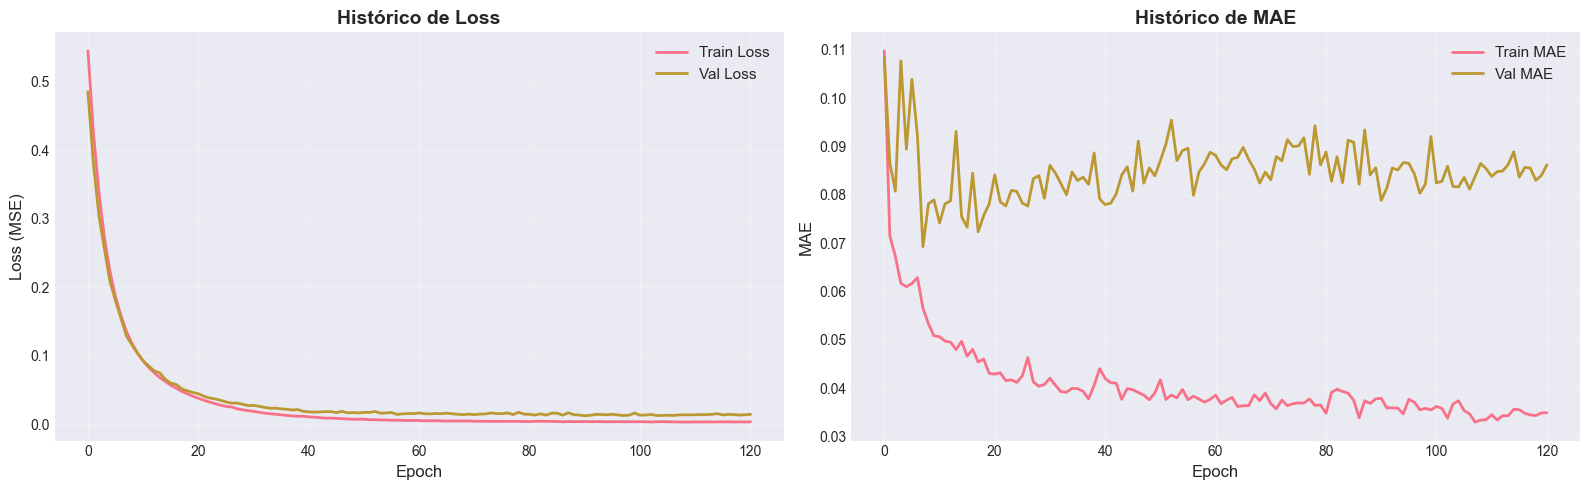


💡 Análise do Treinamento:
   • Início: Loss=0.544948
   • Fim: Loss=0.003532
   • Melhor Val Loss: 0.012486
   ✅ Treinamento aparenta balanceado


In [17]:
print("\n" + "=" * 80)
print("VISUALIZAR HISTÓRICO DE TREINAMENTO")
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.set_title('Histórico de Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(history.history['mae'], label='Train MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('Histórico de MAE', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Análise do Treinamento:")
print(f"   • Início: Loss={history.history['loss'][0]:.6f}")
print(f"   • Fim: Loss={history.history['loss'][-1]:.6f}")
print(f"   • Melhor Val Loss: {min(history.history['val_loss']):.6f}")

if history.history['val_loss'][-1] > min(history.history['val_loss']) * 1.2:
    print("   ⚠️  Possível overfitting (aumentar dropout ou regularização)")
else:
    print("   ✅ Treinamento aparenta balanceado")

In [18]:
print("\n" + "=" * 80)
print("AVALIAR MODELO")
print("=" * 80)

def inverse_transform_predictions(y_true_scaled, y_pred_scaled, scaler_obj, feature_names_list, target_col='Close'):
    """Inverte a normalização das previsões"""
    n_samples = len(y_true_scaled)
    n_features = len(feature_names_list)
    target_idx = feature_names_list.index(target_col)
    
    dummy_true = np.zeros((n_samples, n_features))
    dummy_pred = np.zeros((n_samples, n_features))
    dummy_true[:, target_idx] = y_true_scaled
    dummy_pred[:, target_idx] = y_pred_scaled
    
    y_true_original = scaler_obj.inverse_transform(dummy_true)[:, target_idx]
    y_pred_original = scaler_obj.inverse_transform(dummy_pred)[:, target_idx]
    
    return y_true_original, y_pred_original

def calculate_metrics(y_true, y_pred, name=''):
    """Calcula métricas de avaliação"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    if len(y_true) > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(np.diff(y_pred))
        min_len = min(len(true_dir), len(pred_dir))
        dir_acc = np.mean(true_dir[:min_len] == pred_dir[:min_len]) * 100
    else:
        dir_acc = 0
    
    return {
        'Dataset': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'MAPE (%)': mape,
        'R² Score': r2,
        'Dir. Accuracy (%)': dir_acc
    }

# Fazer previsões
y_train_pred = model.predict(X_train, verbose=0).flatten()
y_val_pred = model.predict(X_val, verbose=0).flatten()
y_test_pred = model.predict(X_test, verbose=0).flatten()

# Inverter normalização
y_train_orig, y_train_pred_orig = inverse_transform_predictions(y_train, y_train_pred, scaler, feature_names)
y_val_orig, y_val_pred_orig = inverse_transform_predictions(y_val, y_val_pred, scaler, feature_names)
y_test_orig, y_test_pred_orig = inverse_transform_predictions(y_test, y_test_pred, scaler, feature_names)

# Calcular métricas
train_metrics = calculate_metrics(y_train_orig, y_train_pred_orig, 'Treino')
val_metrics = calculate_metrics(y_val_orig, y_val_pred_orig, 'Validação')
test_metrics = calculate_metrics(y_test_orig, y_test_pred_orig, 'Teste')

# Exibir resultados
results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])
print("\n" + "=" * 100)
print("MÉTRICAS DE DESEMPENHO")
print("=" * 100)
print(results_df.round(4).to_string(index=False))

print(f"\n✅ Modelo Treinado com Sucesso!")
print(f"   R² Teste: {test_metrics['R² Score']:.4f} ({test_metrics['R² Score']*100:.2f}%)")
print(f"   MAE Teste: ${test_metrics['MAE ($)']:.2f}")


AVALIAR MODELO

MÉTRICAS DE DESEMPENHO
  Dataset  MAE ($)  RMSE ($)  MAPE (%)  R² Score  Dir. Accuracy (%)
   Treino  11.1542   15.4319    4.7735    0.9275            52.3579
Validação  30.1093   39.9254   10.0354    0.7346            51.7045
    Teste  23.8288   28.3536    7.1512    0.8162            48.8764

✅ Modelo Treinado com Sucesso!
   R² Teste: 0.8162 (81.62%)
   MAE Teste: $23.83



VISUALIZAR PREVISÕES vs REAIS


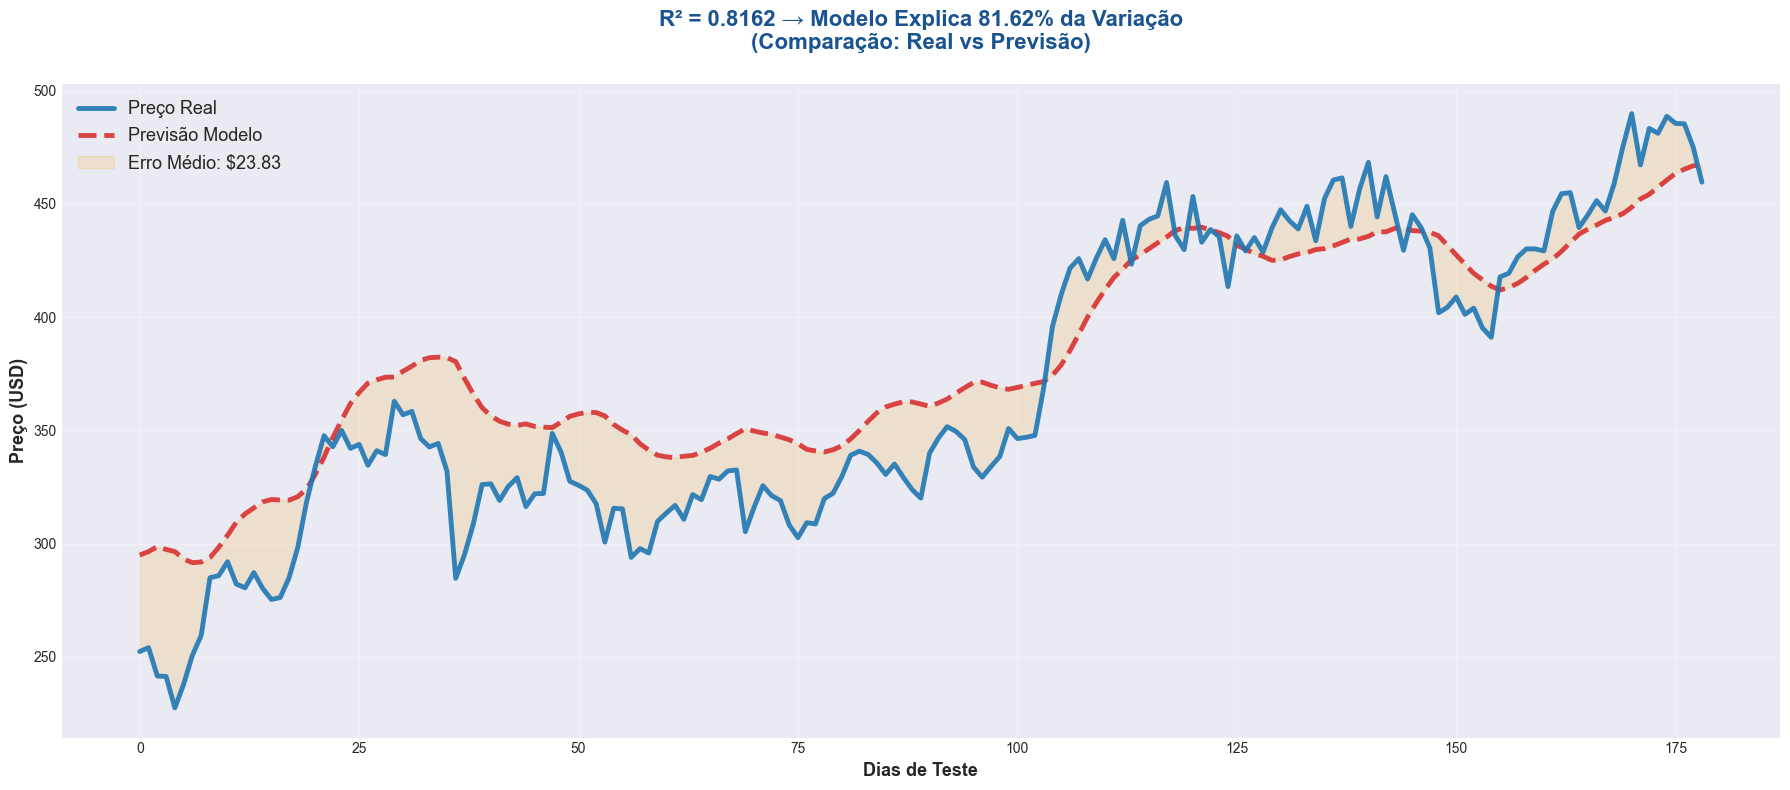


✅ Gráfico gerado com sucesso!


In [19]:
print("\n" + "=" * 80)
print("VISUALIZAR PREVISÕES vs REAIS")
print("=" * 80)

fig, ax = plt.subplots(figsize=(18, 8))

days = range(len(y_test_orig))

ax.plot(days, y_test_orig, label='Preço Real', linewidth=3.5, color='#1f77b4', alpha=0.9, zorder=3)
ax.plot(days, y_test_pred_orig, label='Previsão Modelo', linewidth=3.5, color='#d62728', 
        linestyle='--', alpha=0.85, zorder=2)

mean_error = np.mean(np.abs(y_test_orig - y_test_pred_orig))

ax.fill_between(days, y_test_orig, y_test_pred_orig, alpha=0.15, color='orange', 
                label=f'Erro Médio: ${mean_error:.2f}')

ax.set_title(f'R² = {test_metrics["R² Score"]:.4f} → Modelo Explica {test_metrics["R² Score"]*100:.2f}% da Variação\n(Comparação: Real vs Previsão)', 
             fontsize=16, fontweight='bold', pad=25, color='#1a5490')
ax.set_ylabel('Preço (USD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Dias de Teste', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=13, framealpha=0.95, edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.7)

plt.tight_layout()
plt.show()

print(f"\n✅ Gráfico gerado com sucesso!")

In [20]:
print("\n" + "=" * 80)
print("SALVAR MODELO E ARTEFATOS")
print("=" * 80)

# Caminhos
timestamp_final = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = models_dir / f'lstm_5factor_final_{timestamp_final}.keras'
scaler_path = models_dir / f'scaler_5factor_final_{timestamp_final}.pkl'
config_path = models_dir / f'config_5factor_final_{timestamp_final}.yaml'
results_path = models_dir / f'results_5factor_final_{timestamp_final}.json'

# 1. Salvar modelo
model.save(str(model_path))
print(f"✅ Modelo: {model_path.name}")

# 2. Salvar scaler
joblib.dump(scaler, str(scaler_path))
print(f"✅ Scaler: {scaler_path.name}")

# 3. Salvar configuração
config_final = {
    'model_config': model_config,
    'training_info': {
        'epochs_trained': len(history.history['loss']),
        'final_train_loss': float(history.history['loss'][-1]),
        'final_val_loss': float(history.history['val_loss'][-1]),
        'best_val_loss': float(min(history.history['val_loss'])),
        'timestamp': timestamp_final
    },
    'data_info': {
        'symbol': SYMBOL,
        'start_date': START_DATE,
        'end_date': END_DATE,
        'n_features': len(feature_names),
        'sequence_length': model_config['sequence_length'],
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test)
    },
    'feature_names': feature_names,
    'metrics': {
        'train': train_metrics,
        'validation': val_metrics,
        'test': test_metrics
    }
}

with open(config_path, 'w') as f:
    yaml.dump(config_final, f, default_flow_style=False)
print(f"✅ Configuração: {config_path.name}")

# 4. Salvar resultados
results_final = {
    'metrics': {
        'train': train_metrics,
        'validation': val_metrics,
        'test': test_metrics
    },
    'timestamp': timestamp_final
}

with open(results_path, 'w') as f:
    json.dump(results_final, f, indent=2)
print(f"✅ Resultados: {results_path.name}")

print(f"\n📊 RESUMO FINAL:")
print(f"   R² Teste: {test_metrics['R² Score']:.4f}")
print(f"   MAE Teste: ${test_metrics['MAE ($)']:.2f}")
print(f"   RMSE Teste: ${test_metrics['RMSE ($)']:.2f}")
print(f"\n💾 Arquivo principal: {model_path.name}")


SALVAR MODELO E ARTEFATOS
✅ Modelo: lstm_5factor_final_20260105_185821.keras
✅ Scaler: scaler_5factor_final_20260105_185821.pkl
✅ Configuração: config_5factor_final_20260105_185821.yaml
✅ Resultados: results_5factor_final_20260105_185821.json

📊 RESUMO FINAL:
   R² Teste: 0.8162
   MAE Teste: $23.83
   RMSE Teste: $28.35

💾 Arquivo principal: lstm_5factor_final_20260105_185821.keras
